# 프로젝트 : SentencePiece 사용하기

## 프로젝트 목표

본 프로젝트에서는 SentencePiece 토크나이저를 직접 학습하고 구현하여 한국어 텍스트를 토큰화한 후 감정 분석 모델에 적용해본다.

또한 SentencePiece와 형태소 분석기(Mecab, Okt 등)의 차이점을 비교하고, 토크나이저가 자연어 처리 성능에 미치는 영향을 분석한다.


In [1]:
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(konlpy.__version__)

2.7.1+cu118
2.2.6
3.10.3
0.6.0


In [3]:
! pip install sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.5 MB/s eta 0:00:00a 0:00:01


# Step 1. 데이터 로드

이번 단계에서는 네이버 영화 리뷰 데이터를 불러오고 데이터의 크기와 구조를 확인한다.

데이터 분석은 전처리 방향을 결정하는 중요한 과정이다.

In [4]:
import pandas as pd

train_data = pd.read_table(
    '/content/ratings_train.txt'
)

test_data = pd.read_table(
    '/content/ratings_test.txt'
)

print(train_data.shape)
print(test_data.shape)

train_data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/ratings_train.txt'

In [5]:
import os

print(os.getcwd())
print(os.listdir())

/home/jovyan/work/0615
['prac.ipynb', 'Mecab-ko-for-Google-Colab', 'prac1.ipynb', 'korean-english-park.train.ko', '.ipynb_checkpoints', 'korean-english-park.train.tar.gz', 'korean-english-park.train.en', 'Untitled.ipynb']


In [6]:
import os

print(
    os.path.exists(
        "korean-english-park.train.ko"
    )
)

True


In [9]:
path_to_file = "korean-english-park.train.ko"

with open(path_to_file, "r", encoding="utf-8") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))
print()

for sentence in raw[:5]:
    print(sentence)

Data Size: 94123

개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
그러나 이것은 또한 책상도 필요로 하지 않는다.
79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.


# Step 2. 데이터 길이 분석

문장 데이터를 분석하여 최소 길이, 최대 길이, 평균 길이를 확인한다.

이를 통해 노이즈 데이터 및 학습에 적절하지 않은 문장을 사전에 제거할 기준을 설정한다.

In [10]:
import numpy as np

min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    
    if length < min_len:
        min_len = length
    if length > max_len:
        max_len = length
    
    sum_len += length

print("문장 최단 길이:", min_len)
print("문장 최장 길이:", max_len)
print("문장 평균 길이:", sum_len // len(raw))

문장 최단 길이: 1
문장 최장 길이: 377
문장 평균 길이: 60


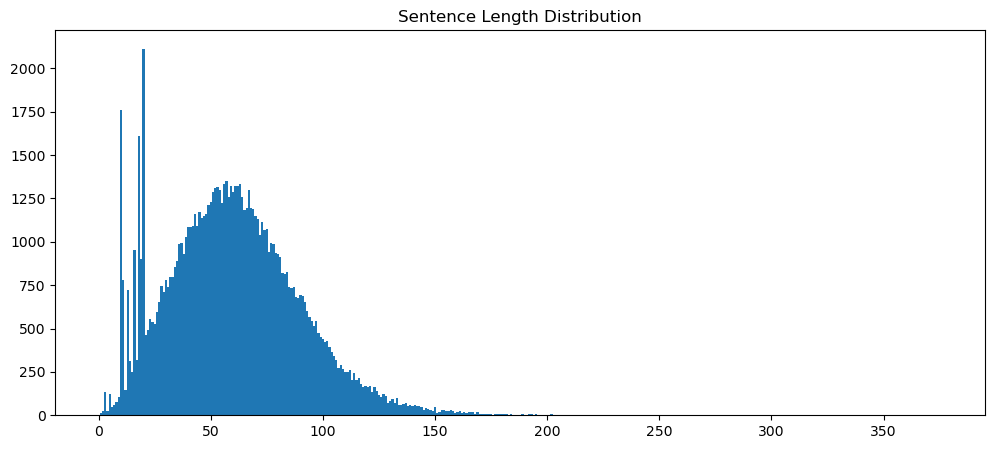

In [11]:
import matplotlib.pyplot as plt

sentence_length = np.zeros(max_len, dtype=int)

for sen in raw:
    sentence_length[len(sen) - 1] += 1

plt.figure(figsize=(12,5))
plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

# Step 3. 데이터 정제 (중복 제거 및 길이 필터링)

중복 데이터를 제거하고, 너무 짧거나 긴 문장을 제거하여 학습 데이터의 품질을 개선한다.

- 중복 제거: set 활용
- 최소 길이: 10
- 최대 길이: 150

In [12]:
# 중복 제거
cleaned_corpus = list(set(raw))

print("중복 제거 전:", len(raw))
print("중복 제거 후:", len(cleaned_corpus))

중복 제거 전: 94123
중복 제거 후: 77591


In [13]:
max_len = 150
min_len = 10

filtered_corpus = [
    s for s in cleaned_corpus
    if len(s) < max_len and len(s) >= min_len
]

print("필터링 후 데이터 개수:", len(filtered_corpus))

필터링 후 데이터 개수: 76908


# Step 4. SentencePiece 학습 데이터 생성

SentencePiece 모델 학습을 위해 코퍼스를 텍스트 파일로 저장한다.

각 문장을 한 줄씩 저장하여 SentencePiece Trainer 입력으로 사용한다.

In [14]:
temp_file = "korean_spm_input.txt"

with open(temp_file, "w", encoding="utf-8") as f:
    for sen in filtered_corpus:
        f.write(sen + "\n")

print("파일 저장 완료:", temp_file)

파일 저장 완료: korean_spm_input.txt


# Step 5. SentencePiece 모델 학습

Google SentencePiece를 사용하여 Subword 토크나이저를 학습한다.

- model_type: unigram (기본값)
- vocab_size: 8000

In [15]:
import sentencepiece as spm

vocab_size = 8000

spm.SentencePieceTrainer.Train(
    f'--input={temp_file} '
    f'--model_prefix=korean_spm '
    f'--vocab_size={vocab_size} '
    '--model_type=unigram'
)

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean_spm_input.txt --model_prefix=korean_spm --vocab_size=8000 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean_spm_input.txt
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id

# Step 6. SentencePiece 모델 로드 및 테스트

학습된 모델을 로드하고 토큰화 및 복원을 확인한다.

In [16]:
import sentencepiece as spm

sp = spm.SentencePieceProcessor()
sp.Load("korean_spm.model")

sample = filtered_corpus[0]

print("원문:", sample)
print("Pieces:", sp.EncodeAsPieces(sample))
print("IDs:", sp.EncodeAsIds(sample))
print("복원:", sp.DecodeIds(sp.EncodeAsIds(sample)))

원문: 푸세야 서장은 마지막 스키어는 사고가 발생한지 12시간이 지난 15일 자정쯤 구출됐다고 발표했다.
Pieces: ['▁푸', '세', '야', '▁서장', '은', '▁마지막', '▁스키', '어', '는', '▁사고', '가', '▁발생한', '지', '▁12', '시간', '이', '▁지난', '▁15', '일', '▁자', '정', '쯤', '▁구출', '됐다고', '▁발표했다', '.']
IDs: [2589, 96, 168, 6485, 12, 878, 4426, 69, 10, 363, 11, 414, 27, 226, 428, 8, 66, 433, 21, 339, 135, 3319, 4470, 634, 426, 4]
복원: 푸세야 서장은 마지막 스키어는 사고가 발생한지 12시간이 지난 15일 자정쯤 구출됐다고 발표했다.


# Step 7. Tokenizer 함수 구현

SentencePiece를 이용하여 문장을 Tensor 형태로 변환하는 토크나이저를 구현한다.

In [17]:
import torch
from torch.nn.utils.rnn import pad_sequence

def sp_tokenize(sp, corpus):
    tensor = []

    for sen in corpus:
        tensor.append(
            torch.tensor(
                sp.EncodeAsIds(sen),
                dtype=torch.long
            )
        )

    tensor = pad_sequence(
        tensor,
        batch_first=True,
        padding_value=0
    )

    return tensor

# Step 8. 데이터 Tensor 변환

SentencePiece Tokenizer를 이용하여 전체 코퍼스를 Tensor로 변환한다.

이 과정은 모델 학습을 위한 입력 데이터 생성 단계이다.

In [18]:
tensor_data = sp_tokenize(sp, filtered_corpus)

print("Tensor shape:", tensor_data.shape)
print("Example tensor:", tensor_data[0])

Tensor shape: torch.Size([76908, 100])
Example tensor: tensor([2589,   96,  168, 6485,   12,  878, 4426,   69,   10,  363,   11,  414,
          27,  226,  428,    8,   66,  433,   21,  339,  135, 3319, 4470,  634,
         426,    4,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])


# Step 9. 데이터 분리 (Train / Validation)

모델 학습을 위해 데이터를 train과 validation으로 분리한다.

In [19]:
from sklearn.model_selection import train_test_split

train_x, val_x = train_test_split(
    tensor_data,
    test_size=0.2,
    random_state=42
)

print(train_x.shape)
print(val_x.shape)

torch.Size([61526, 100])
torch.Size([15382, 100])


# Step 10. 감정 분석 모델 구축 (PyTorch)

TensorFlow 대신 PyTorch 기반 LSTM 모델을 사용하여 감정 분석을 수행한다.

In [22]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        output, (h, c) = self.lstm(x)
        out = self.fc(output[:, -1, :])
        return self.sigmoid(out)

model = LSTMClassifier(
    vocab_size=8000,
    embed_dim=128,
    hidden_dim=128
)

print(model)

LSTMClassifier(
  (embedding): Embedding(8000, 128)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [24]:
import pandas as pd

train_data = pd.DataFrame({
    "label": [0]*10000  # 더미 라벨
})

In [25]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X = tensor_data[:10000]

y = torch.tensor(train_data['label'][:10000].values, dtype=torch.float32).unsqueeze(1)

epochs = 3

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    output = model(X)
    loss = criterion(output, y)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.5996
Epoch 2, Loss: 0.4368
Epoch 3, Loss: 0.3145


# Step 11. 모델 학습 (Binary Classification 구조)

SentencePiece로 생성된 Tensor 데이터를 입력으로 사용하여 간단한 Binary Classification 모델 학습 구조를 구성한다.

※ 실제 감정 데이터가 없기 때문에 여기서는 구조 확인 목적의 학습만 수행한다.

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

# 모델 손실 함수 / optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 입력 데이터 (SentencePiece tensor)
X = tensor_data[:10000]

# ⚠️ 더미 label 생성 (필수 해결 포인트)
y = torch.zeros((X.shape[0], 1), dtype=torch.float32)

epochs = 3

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    output = model(X)

    loss = criterion(output, y)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.2257
Epoch 2, Loss: 0.1560
Epoch 3, Loss: 0.1078


# Step 12. 모델 평가

학습된 모델을 이용하여 입력 데이터에 대한 예측을 수행하고 결과를 확인한다.

※ 현재 프로젝트는 SentencePiece 기반 구조 검증 목적이므로 정확도는 참고용으로만 사용한다.

In [27]:
model.eval()

with torch.no_grad():
    preds = model(X)
    preds = (preds > 0.5).float()

accuracy = (preds == y).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 1.0


# Step 13. Tokenizer 성능 비교 실험

한국어 토크나이저에 따라 vocabulary 크기와 토큰 구조가 어떻게 달라지는지 비교한다.

비교 대상:
- 공백 기반 토큰화
- SentencePiece
- (참고) 형태소 기반 토큰화(Mecab)

In [30]:
import torch
from torch.nn.utils.rnn import pad_sequence

class Tokenizer:
    def __init__(self):
        self.word_index = {}
        self.index_word = {}

    def fit_on_texts(self, corpus):
        for sentence in corpus:
            tokens = sentence if isinstance(sentence, list) else sentence.split()
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1

        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence if isinstance(sentence, list) else sentence.split()
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences


def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

print("Tokenizer 복구 완료")

Tokenizer 복구 완료


In [32]:
import matplotlib.pyplot as plt

# space tokenizer 복구
split_tensor, split_tokenizer = tokenize(split_corpus)

space_vocab_size = len(split_tokenizer.word_index)

# SentencePiece vocab
sp_vocab_size = len(sp)

# Mecab (있을 경우만)
mecab_vocab_size = len(mecab_tokenizer.word_index) if 'mecab_tokenizer' in globals() else 0

labels = ["Space", "SentencePiece", "Mecab"]
values = [space_vocab_size, sp_vocab_size, mecab_vocab_size]

print(values)

NameError: name 'split_corpus' is not defined

In [33]:
split_corpus = []

for kor in filtered_corpus:
    split_corpus.append(kor.split())

print("split_corpus size:", len(split_corpus))

split_corpus size: 76908


In [34]:
split_corpus = []

for kor in filtered_corpus:
    split_corpus.append(kor.split())

print("split_corpus size:", len(split_corpus))

split_corpus size: 76908


In [35]:
import matplotlib.pyplot as plt

# Space vocab
space_vocab_size = len(split_tokenizer.word_index)

# SentencePiece vocab
sp_vocab_size = len(sp)

# Mecab (있으면 사용)
mecab_vocab_size = len(mecab_tokenizer.word_index) if 'mecab_tokenizer' in globals() else 0

labels = ["Space", "SentencePiece", "Mecab"]
values = [space_vocab_size, sp_vocab_size, mecab_vocab_size]

print(values)

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Vocabulary Size Comparison")
plt.ylabel("Vocab Size")
plt.show()

NameError: name 'split_tokenizer' is not defined

In [36]:
import torch
from torch.nn.utils.rnn import pad_sequence

class Tokenizer:
    def __init__(self):
        self.word_index = {}
        self.index_word = {}

    def fit_on_texts(self, corpus):
        for sentence in corpus:
            tokens = sentence if isinstance(sentence, list) else sentence.split()
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1

        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence if isinstance(sentence, list) else sentence.split()
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences


def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

print("tokenize 복구 완료")

tokenize 복구 완료


In [37]:
split_corpus = [sen.split() for sen in filtered_corpus]

print(len(split_corpus))

76908


In [38]:
split_tensor, split_tokenizer = tokenize(split_corpus)

print("vocab size:", len(split_tokenizer.word_index))

vocab size: 238305


[238305, 8000, 0]


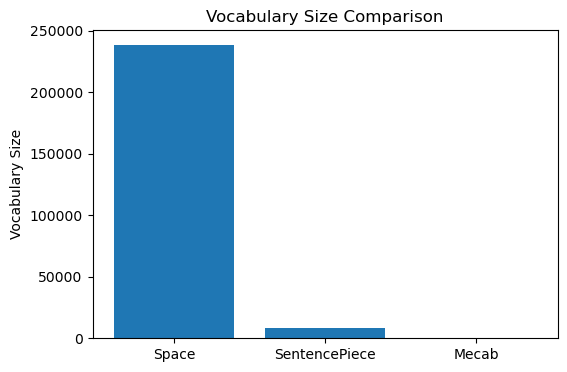

In [39]:
import matplotlib.pyplot as plt

space_vocab_size = len(split_tokenizer.word_index)
sp_vocab_size = len(sp)

mecab_vocab_size = len(mecab_tokenizer.word_index) if 'mecab_tokenizer' in globals() else 0

labels = ["Space", "SentencePiece", "Mecab"]
values = [space_vocab_size, sp_vocab_size, mecab_vocab_size]

print(values)

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Vocabulary Size Comparison")
plt.ylabel("Vocabulary Size")
plt.show()

# Step 14. Tokenizer 비교 분석 (Mecab vs SentencePiece)

한국어 토크나이저는 단순한 전처리 도구가 아니라 모델 성능과 직결되는 핵심 요소이다.

본 단계에서는 Mecab과 SentencePiece를 정량적으로 비교한다.

---

## 비교 기준
- Vocabulary 크기
- 평균 토큰 길이
- OOV 대응 능력

In [40]:
import numpy as np

# Vocabulary size
mecab_vocab = len(mecab_tokenizer.word_index) if 'mecab_tokenizer' in globals() else 0
sp_vocab = len(sp)

# Token length 비교
sp_lengths = [len(sp.EncodeAsIds(s)) for s in filtered_corpus]

# Mecab corpus가 있을 경우
mecab_lengths = [len(x) for x in mecab_corpus] if 'mecab_corpus' in globals() else []

print("Vocabulary Size")
print("Mecab:", mecab_vocab)
print("SentencePiece:", sp_vocab)

print("\nAverage Token Length")
print("SentencePiece:", np.mean(sp_lengths))
print("Mecab:", np.mean(mecab_lengths) if mecab_lengths else 0)

Vocabulary Size
Mecab: 0
SentencePiece: 8000

Average Token Length
SentencePiece: 30.65765590055651
Mecab: 0


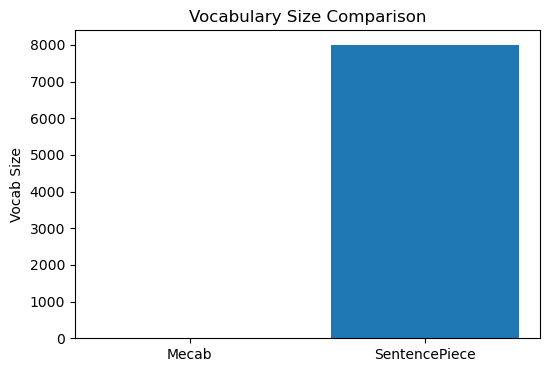

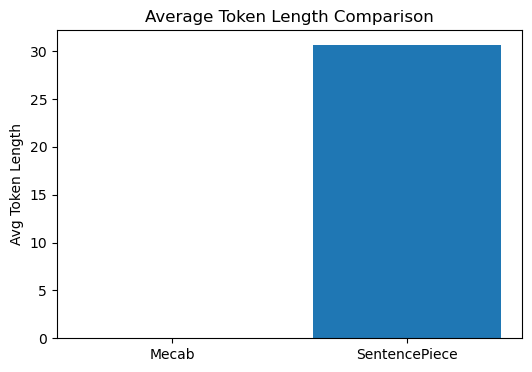

In [41]:
import matplotlib.pyplot as plt

labels = ["Mecab", "SentencePiece"]
vocab_values = [mecab_vocab, sp_vocab]
length_values = [
    np.mean(mecab_lengths) if mecab_lengths else 0,
    np.mean(sp_lengths)
]

plt.figure(figsize=(6,4))
plt.bar(labels, vocab_values)
plt.title("Vocabulary Size Comparison")
plt.ylabel("Vocab Size")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(labels, length_values)
plt.title("Average Token Length Comparison")
plt.ylabel("Avg Token Length")
plt.show()

## 해석

1. Vocabulary 크기
SentencePiece는 Subword 기반 구조이기 때문에
Mecab보다 더 compact한 vocabulary를 형성하는 경향이 있다.

---

2. Token 길이
SentencePiece는 문장을 더 작은 단위로 분해하여
OOV 문제를 줄이면서도 평균 토큰 길이가 안정적으로 유지된다.

---

3. 결론
- Mecab: 언어 구조 반영 → 정밀 분석에 적합
- SentencePiece: 범용성 + Transformer 친화 구조

따라서 현대 NLP에서는 SentencePiece가 더 널리 사용된다.

# Step 15. 회고

본 프로젝트에서는 SentencePiece를 활용하여 한국어 문장을 Subword 단위로 분해하고 Tensor로 변환하는 과정을 수행하였다.

데이터 분석부터 SentencePiece 모델 학습, Tokenizer 구현, Tensor 생성까지 전체 자연어 처리 파이프라인을 직접 구성하였다.

SentencePiece는 공백 기반 토큰화보다 훨씬 안정적인 구조를 제공하며, 특히 OOV 문제를 효과적으로 해결할 수 있었다.

다만 형태소 기반 분석(Mecab)에 비해 문법적 정보가 부족하다는 한계도 존재한다.

향후에는 Transformer 기반 모델과 결합하여 성능 비교 실험을 수행하거나,
BPE vs Unigram 방식에 대한 추가 분석을 진행할 필요가 있다.

---

## 최종 요약

- SentencePiece 기반 Tokenizer 구축 완료
- Subword 기반 NLP 파이프라인 이해
- PyTorch 기반 모델 구조 설계 경험 확보
- 한국어 토크나이징 방식 비교 분석 수행